In [2]:
import numpy as np
import pandas as pd
pd.options.display.max_columns=20 #DataFrameの表示の際に、最大20列まで表示
pd.options.display.max_rows=20     #DataFrameの表示の際に、最大20行まで表示
pd.options.display.max_colwidth=80 #1つのセルに表示される文字数を最大80文字に制限
np.set_printoptions(precision=4,suppress=True) #小数点以下4桁まで表示かつ非常に小さい数を指数表記(e-05 とか)にしない

In [7]:
path="example.txt"

In [8]:
with open(path) as f:
    print(f.readline())

{ "a": "Mozilla\/5.0 (Windows NT 6.1; WOW64) AppleWebKit\/535.11 (KHTML, like Gecko) Chrome\/17.0.963.78 Safari\/535.11", "c": "US", "nk": 1, "tz": "America\/New_York", "gr": "MA", "g": "A6qOVH", "h": "wfLQtf", "l": "orofrog", "al": "en-US,en;q=0.8", "hh": "1.usa.gov", "r": "http:\/\/www.facebook.com\/l\/7AQEFzjSi\/1.usa.gov\/wfLQtf", "u": "http:\/\/www.ncbi.nlm.nih.gov\/pubmed\/22415991", "t": 1331923247, "hc": 1331822918, "cy": "Danvers", "ll": [ 42.576698, -70.954903 ] }



In [9]:
import json
with open(path) as f:
    records=[json.loads(line) for line in f]

In [10]:
records[0]

{'a': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.78 Safari/535.11',
 'c': 'US',
 'nk': 1,
 'tz': 'America/New_York',
 'gr': 'MA',
 'g': 'A6qOVH',
 'h': 'wfLQtf',
 'l': 'orofrog',
 'al': 'en-US,en;q=0.8',
 'hh': '1.usa.gov',
 'r': 'http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf',
 'u': 'http://www.ncbi.nlm.nih.gov/pubmed/22415991',
 't': 1331923247,
 'hc': 1331822918,
 'cy': 'Danvers',
 'll': [42.576698, -70.954903]}

In [12]:
time_zones=[rec["tz"] for rec in records if "tz" in rec]

In [13]:
time_zones[:10]

['America/New_York',
 'America/Denver',
 'America/New_York',
 'America/Sao_Paulo',
 'America/New_York',
 'America/New_York',
 'Europe/Warsaw',
 '',
 '',
 '']

In [18]:
def get_counts(sequence):
    counts={}
    for x in sequence:
        if x in counts:
            counts[x]+=1
        else:
            counts[x]=1
    return counts

In [19]:
from collections import defaultdict

In [20]:
def get_counts2(sequence):
    counts=defaultdict(int)
    for x in sequence:
        counts[x]+=1
    return counts

In [24]:
counts=get_counts2(time_zones)

In [25]:
counts["America/New_York"]

1251

In [26]:
len(time_zones)

3440

In [27]:
def top_counts(count_dict,n=10):
    value_key_pairs=[(count,tz) for tz,count in count_dict.items()]
    value_key_pairs.sort()
    return value_key_pairs[-n:]

In [28]:
top_counts(counts)

[(33, 'America/Sao_Paulo'),
 (35, 'Europe/Madrid'),
 (36, 'Pacific/Honolulu'),
 (37, 'Asia/Tokyo'),
 (74, 'Europe/London'),
 (191, 'America/Denver'),
 (382, 'America/Los_Angeles'),
 (400, 'America/Chicago'),
 (521, ''),
 (1251, 'America/New_York')]

In [29]:
from collections import Counter

In [30]:
counts=Counter(time_zones)

In [31]:
counts.most_common(10)

[('America/New_York', 1251),
 ('', 521),
 ('America/Chicago', 400),
 ('America/Los_Angeles', 382),
 ('America/Denver', 191),
 ('Europe/London', 74),
 ('Asia/Tokyo', 37),
 ('Pacific/Honolulu', 36),
 ('Europe/Madrid', 35),
 ('America/Sao_Paulo', 33)]

In [32]:
frame=pd.DataFrame(records)

In [33]:
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3560 entries, 0 to 3559
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a            3440 non-null   object 
 1   c            2919 non-null   object 
 2   nk           3440 non-null   float64
 3   tz           3440 non-null   object 
 4   gr           2919 non-null   object 
 5   g            3440 non-null   object 
 6   h            3440 non-null   object 
 7   l            3440 non-null   object 
 8   al           3094 non-null   object 
 9   hh           3440 non-null   object 
 10  r            3440 non-null   object 
 11  u            3440 non-null   object 
 12  t            3440 non-null   float64
 13  hc           3440 non-null   float64
 14  cy           2919 non-null   object 
 15  ll           2919 non-null   object 
 16  _heartbeat_  120 non-null    float64
 17  kw           93 non-null     object 
dtypes: float64(4), object(14)
memory usage: 500.8+ K

In [34]:
frame["tz"].head()

0     America/New_York
1       America/Denver
2     America/New_York
3    America/Sao_Paulo
4     America/New_York
Name: tz, dtype: object

In [35]:
tz_counts=frame["tz"].value_counts()

In [36]:
tz_counts.head()

tz
America/New_York       1251
                        521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Name: count, dtype: int64

In [37]:
clean_tz=frame["tz"].fillna("Missing")

In [38]:
clean_tz[clean_tz==""]="Unknown"

In [41]:
tz_counts=clean_tz.value_counts()

In [42]:
tz_counts.head()

tz
America/New_York       1251
Unknown                 521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Name: count, dtype: int64

In [43]:
import seaborn as sns

In [44]:
subset=tz_counts.head()

<Axes: ylabel='tz'>

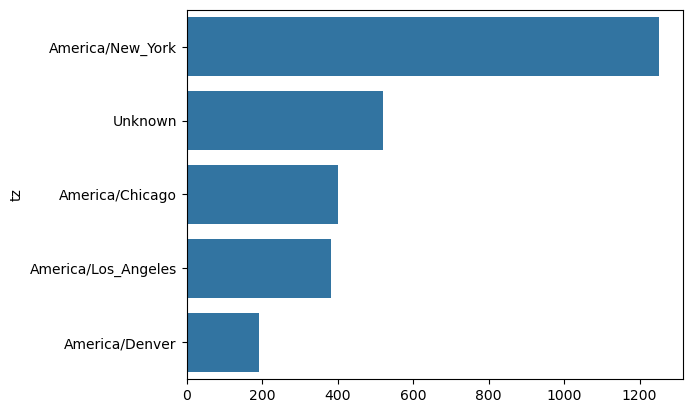

In [45]:
sns.barplot(y=subset.index,x=subset.to_numpy())

In [46]:
frame["a"][1]

'GoogleMaps/RochesterNY'

In [47]:
frame["a"][50]

'Mozilla/5.0 (Windows NT 5.1; rv:10.0.2) Gecko/20100101 Firefox/10.0.2'

In [48]:
frame["a"][51][:50]

'Mozilla/5.0 (Linux; U; Android 2.2.2; en-us; LG-P9'

In [49]:
results=pd.Series([x.split()[0] for x in frame["a"].dropna()])

In [50]:
results.head(5)

0               Mozilla/5.0
1    GoogleMaps/RochesterNY
2               Mozilla/4.0
3               Mozilla/5.0
4               Mozilla/5.0
dtype: object

In [51]:
results.value_counts().head(8)

Mozilla/5.0                 2594
Mozilla/4.0                  601
GoogleMaps/RochesterNY       121
Opera/9.80                    34
TEST_INTERNET_AGENT           24
GoogleProducer                21
Mozilla/6.0                    5
BlackBerry8520/5.0.0.681       4
Name: count, dtype: int64

In [52]:
cframe=frame[frame["a"].notna()].copy()

In [54]:
cframe["os"]=np.where(cframe["a"].str.contains("Windows"),"Windows","Not Windows")

In [55]:
cframe["os"].head(5)

0        Windows
1    Not Windows
2        Windows
3    Not Windows
4        Windows
Name: os, dtype: object

In [56]:
by_tz_os=cframe.groupby(["tz","os"])

In [57]:
agg_counts=by_tz_os.size().unstack().fillna(0)

In [58]:
agg_counts.head()

os,Not Windows,Windows
tz,,
,245.0,276.0
Africa/Cairo,0.0,3.0
Africa/Casablanca,0.0,1.0
Africa/Ceuta,0.0,2.0
Africa/Johannesburg,0.0,1.0


In [59]:
indexer=agg_counts.sum("columns").argsort()

In [60]:
indexer.values[:10]

array([ 2,  7,  5,  4, 14, 11,  9,  8, 24, 26])

In [61]:
count_subset=agg_counts.take(indexer[-10:])

In [62]:
count_subset

os,Not Windows,Windows
tz,,
America/Sao_Paulo,13.0,20.0
Europe/Madrid,16.0,19.0
Pacific/Honolulu,0.0,36.0
Asia/Tokyo,2.0,35.0
Europe/London,43.0,31.0
America/Denver,132.0,59.0
America/Los_Angeles,130.0,252.0
America/Chicago,115.0,285.0
,245.0,276.0


In [63]:
agg_counts.sum(axis="columns").nlargest(10)

tz
America/New_York       1251.0
                        521.0
America/Chicago         400.0
America/Los_Angeles     382.0
America/Denver          191.0
Europe/London            74.0
Asia/Tokyo               37.0
Pacific/Honolulu         36.0
Europe/Madrid            35.0
America/Sao_Paulo        33.0
dtype: float64

In [64]:
count_subset=count_subset.stack()

In [65]:
count_subset.name="total"

In [66]:
count_subset=count_subset.reset_index()

In [67]:
count_subset.head(10)

,tz,os,total
0,America/Sao_Paulo,Not Windows,13.0
1,America/Sao_Paulo,Windows,20.0
2,Europe/Madrid,Not Windows,16.0
3,Europe/Madrid,Windows,19.0
4,Pacific/Honolulu,Not Windows,0.0
5,Pacific/Honolulu,Windows,36.0
6,Asia/Tokyo,Not Windows,2.0
7,Asia/Tokyo,Windows,35.0
8,Europe/London,Not Windows,43.0
9,Europe/London,Windows,31.0


<Axes: xlabel='total', ylabel='tz'>

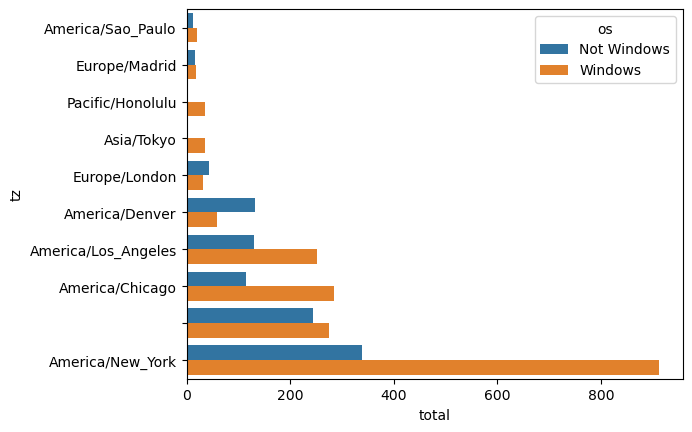

In [68]:
sns.barplot(x="total",y="tz",hue="os",data=count_subset)

In [70]:
def norm_total(group):
    group["normed_total"]=group["total"]/group["total"].sum()
    return group

In [72]:
results=count_subset.groupby("tz").apply(norm_total,include_groups=False)

<Axes: xlabel='normed_total', ylabel='tz'>

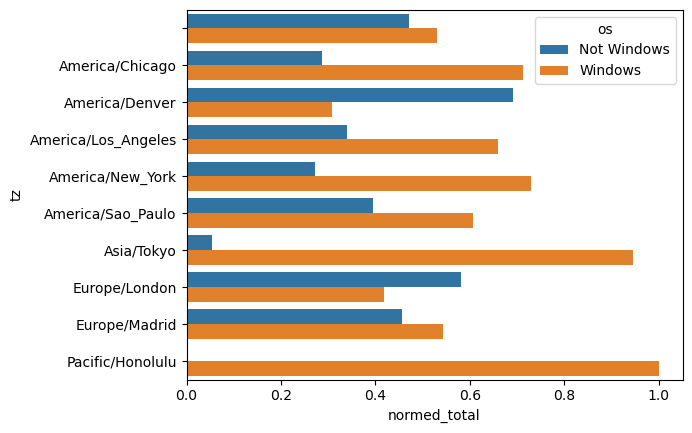

In [73]:
sns.barplot(x="normed_total",y="tz",hue="os",data=results)

In [74]:
g=count_subset.groupby("tz")

In [75]:
results2=count_subset["total"]/g["total"].transform("sum")

In [119]:
unames=["user_id","gender","age","occupation","zip"]
users=pd.read_table("users.dat",sep="::",
                   header=None,names=unames,engine="python")

In [120]:
rnames=["user_id","movie_id","rating","timestamp"]
ratings=pd.read_table("ratings.dat",sep="::",
                     header=None,names=rnames,engine="python")

In [121]:
mnames=["movie_id","title","genres"]
movie=pd.read_table("movies.dat",sep="::",
                   header=None,names=mnames,engine="python")

In [122]:
users.head(5)

,user_id,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [123]:
ratings.head(5)

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [124]:
movie.head(5)

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [125]:
ratings

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [126]:
data=pd.merge(pd.merge(ratings,users),movie)

In [127]:
data

,user_id,movie_id,rating,timestamp,gender,age,occupation,zip,title,genres
0,1,1193,5,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,F,1,10,48067,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy
...,...,...,...,...,...,...,...,...,...,...
1000204,6040,1091,1,956716541,M,25,6,11106,Weekend at Bernie's (1989),Comedy
1000205,6040,1094,5,956704887,M,25,6,11106,"Crying Game, The (1992)",Drama|Romance|War
1000206,6040,562,5,956704746,M,25,6,11106,Welcome to the Dollhouse (1995),Comedy|Drama
1000207,6040,1096,4,956715648,M,25,6,11106,Sophie's Choice (1982),Drama


In [128]:
data.iloc[0]

user_id                                            1
movie_id                                        1193
rating                                             5
timestamp                                  978300760
gender                                             F
age                                                1
occupation                                        10
zip                                            48067
title         One Flew Over the Cuckoo's Nest (1975)
genres                                         Drama
Name: 0, dtype: object

In [129]:
mean_ratings=data.pivot_table("rating",index="title",
                             columns="gender",aggfunc="mean")

In [130]:
mean_ratings.head(5)

gender,F,M
title,,
"$1,000,000 Duck (1971)",3.375000,2.761905
'Night Mother (1986),3.388889,3.352941
'Til There Was You (1997),2.675676,2.733333
"'burbs, The (1989)",2.793478,2.962085
...And Justice for All (1979),3.828571,3.689024


In [131]:
ratings_by_title=data.groupby("title").size()

In [132]:
ratings_by_title

title
$1,000,000 Duck (1971)                         37
'Night Mother (1986)                           70
'Til There Was You (1997)                      52
'burbs, The (1989)                            303
...And Justice for All (1979)                 199
                                             ... 
Zed & Two Noughts, A (1985)                    29
Zero Effect (1998)                            301
Zero Kelvin (Kjærlighetens kjøtere) (1995)      2
Zeus and Roxanne (1997)                        23
eXistenZ (1999)                               410
Length: 3706, dtype: int64

In [133]:
active_titles=ratings_by_title.index[ratings_by_title>=250]

In [134]:
active_titles

Index([''burbs, The (1989)', '10 Things I Hate About You (1999)',
       '101 Dalmatians (1961)', '101 Dalmatians (1996)', '12 Angry Men (1957)',
       '13th Warrior, The (1999)', '2 Days in the Valley (1996)',
       '20,000 Leagues Under the Sea (1954)', '2001: A Space Odyssey (1968)',
       '2010 (1984)',
       ...
       'X-Men (2000)', 'Year of Living Dangerously (1982)',
       'Yellow Submarine (1968)', 'You've Got Mail (1998)',
       'Young Frankenstein (1974)', 'Young Guns (1988)',
       'Young Guns II (1990)', 'Young Sherlock Holmes (1985)',
       'Zero Effect (1998)', 'eXistenZ (1999)'],
      dtype='object', name='title', length=1216)

In [135]:
mean_ratings=mean_ratings.loc[active_titles]

In [136]:
mean_ratings

gender,F,M
title,,
"'burbs, The (1989)",2.793478,2.962085
10 Things I Hate About You (1999),3.646552,3.311966
101 Dalmatians (1961),3.791444,3.500000
101 Dalmatians (1996),3.240000,2.911215
12 Angry Men (1957),4.184397,4.328421
...,...,...
Young Guns (1988),3.371795,3.425620
Young Guns II (1990),2.934783,2.904025
Young Sherlock Holmes (1985),3.514706,3.363344


In [137]:
top_female_ratings=mean_ratings.sort_values("F",ascending=False)

In [138]:
top_female_ratings

gender,F,M
title,,
"Close Shave, A (1995)",4.644444,4.473795
"Wrong Trousers, The (1993)",4.588235,4.478261
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.572650,4.464589
Wallace & Gromit: The Best of Aardman Animation (1996),4.563107,4.385075
Schindler's List (1993),4.562602,4.491415
...,...,...
"Avengers, The (1998)",1.915254,2.017467
Speed 2: Cruise Control (1997),1.906667,1.863014
Rocky V (1990),1.878788,2.132780


In [139]:
mean_ratings["diff"]=mean_ratings["M"]-mean_ratings["F"]

In [140]:
sorted_by_diff=mean_ratings.sort_values("diff")

In [141]:
sorted_by_diff.head()

gender,F,M,diff
title,,,
Dirty Dancing (1987),3.790378,2.959596,-0.830782
Jumpin' Jack Flash (1986),3.254717,2.578358,-0.676359
Grease (1978),3.975265,3.367041,-0.608224
Little Women (1994),3.870588,3.321739,-0.548849
Steel Magnolias (1989),3.901734,3.365957,-0.535777


In [142]:
sorted_by_diff[::-1].head()

gender,F,M,diff
title,,,
"Good, The Bad and The Ugly, The (1966)",3.494949,4.221300,0.726351
"Kentucky Fried Movie, The (1977)",2.878788,3.555147,0.676359
Dumb & Dumber (1994),2.697987,3.336595,0.638608
"Longest Day, The (1962)",3.411765,4.031447,0.619682
"Cable Guy, The (1996)",2.250000,2.863787,0.613787


In [143]:
rating_std_by_title=data.groupby("title")["rating"].std()

In [144]:
rating_std_by_title=rating_std_by_title.loc[active_titles]

In [145]:
rating_std_by_title

title
'burbs, The (1989)                   1.107760
10 Things I Hate About You (1999)    0.989815
101 Dalmatians (1961)                0.982103
101 Dalmatians (1996)                1.098717
12 Angry Men (1957)                  0.812731
                                       ...   
Young Guns (1988)                    1.017437
Young Guns II (1990)                 1.071959
Young Sherlock Holmes (1985)         0.891176
Zero Effect (1998)                   1.042932
eXistenZ (1999)                      1.178568
Name: rating, Length: 1216, dtype: float64

In [146]:
rating_std_by_title.sort_values(ascending=False)[:10]

title
Dumb & Dumber (1994)                     1.321333
Blair Witch Project, The (1999)          1.316368
Natural Born Killers (1994)              1.307198
Tank Girl (1995)                         1.277695
Rocky Horror Picture Show, The (1975)    1.260177
Eyes Wide Shut (1999)                    1.259624
Evita (1996)                             1.253631
Billy Madison (1995)                     1.249970
Fear and Loathing in Las Vegas (1998)    1.246408
Bicentennial Man (1999)                  1.245533
Name: rating, dtype: float64

In [147]:
movie["genres"].head()

0     Animation|Children's|Comedy
1    Adventure|Children's|Fantasy
2                  Comedy|Romance
3                    Comedy|Drama
4                          Comedy
Name: genres, dtype: object

In [148]:
movie["genres"].head().str.split("|")

0     [Animation, Children's, Comedy]
1    [Adventure, Children's, Fantasy]
2                   [Comedy, Romance]
3                     [Comedy, Drama]
4                            [Comedy]
Name: genres, dtype: object

In [149]:
movie["genre"]=movie.pop("genres").str.split("|")

In [150]:
movie.head()

,movie_id,title,genre
0,1,Toy Story (1995),"[Animation, Children's, Comedy]"
1,2,Jumanji (1995),"[Adventure, Children's, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama]"
4,5,Father of the Bride Part II (1995),[Comedy]


In [151]:
movie_exploded=movie.explode("genre")

In [152]:
movie_exploded[:10]

,movie_id,title,genre
0,1,Toy Story (1995),Animation
0,1,Toy Story (1995),Children's
0,1,Toy Story (1995),Comedy
1,2,Jumanji (1995),Adventure
1,2,Jumanji (1995),Children's
1,2,Jumanji (1995),Fantasy
2,3,Grumpier Old Men (1995),Comedy
2,3,Grumpier Old Men (1995),Romance
3,4,Waiting to Exhale (1995),Comedy
3,4,Waiting to Exhale (1995),Drama


In [153]:
ratings_with_genre=pd.merge(pd.merge(movie_exploded,ratings),users)

In [154]:
ratings_with_genre.iloc[0]

movie_id                     1
title         Toy Story (1995)
genre                Animation
user_id                      1
rating                       5
timestamp            978824268
gender                       F
age                          1
occupation                  10
zip                      48067
Name: 0, dtype: object

In [157]:
genre_ratings=(ratings_with_genre.groupby(["genre","age"])["rating"].mean().unstack("age"))

In [158]:
genre_ratings[:10]

age,1,18,25,35,45,50,56
genre,,,,,,,
Action,3.506385,3.447097,3.453358,3.538107,3.528543,3.611333,3.610709
Adventure,3.449975,3.408525,3.443163,3.515291,3.528963,3.628163,3.649064
Animation,3.476113,3.624014,3.701228,3.740545,3.734856,3.780020,3.756233
Children's,3.241642,3.294257,3.426873,3.518423,3.527593,3.556555,3.621822
Comedy,3.497491,3.460417,3.490385,3.561984,3.591789,3.646868,3.650949
Crime,3.710170,3.668054,3.680321,3.733736,3.750661,3.810688,3.832549
Documentary,3.730769,3.865865,3.946690,3.953747,3.966521,3.908108,3.961538
Drama,3.794735,3.721930,3.726428,3.782512,3.784356,3.878415,3.933465
Fantasy,3.317647,3.353778,3.452484,3.482301,3.532468,3.581570,3.532700


In [159]:
names1880=pd.read_csv("yob1880.txt",names=["name","sex","births"])

In [160]:
names1880

,name,sex,births
0,Mary,F,7065
1,Anna,F,2604
2,Emma,F,2003
3,Elizabeth,F,1939
4,Minnie,F,1746
...,...,...,...
1995,Woodie,M,5
1996,Worthy,M,5
1997,Wright,M,5
1998,York,M,5


In [161]:
names1880.groupby("sex")["births"].sum()

sex
F     90993
M    110493
Name: births, dtype: int64

In [163]:
pieces=[]
for year in range(1880,2011):
    path=f"yob{year}.txt"
    frame=pd.read_csv(path,names=["name","sex","births"])
    frame["year"]=year
    pieces.append(frame)
names=pd.concat(pieces,ignore_index=True)

In [164]:
names

,name,sex,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
...,...,...,...,...
1690779,Zymaire,M,5,2010
1690780,Zyonne,M,5,2010
1690781,Zyquarius,M,5,2010
1690782,Zyran,M,5,2010


In [166]:
total_births=names.pivot_table("births",index="year",columns="sex",aggfunc="sum")

In [167]:
total_births.tail()

sex,F,M
year,,
2006,1896468,2050234
2007,1916888,2069242
2008,1883645,2032310
2009,1827643,1973359
2010,1759010,1898382


<Axes: title={'center': 'Total births by sex and year'}, xlabel='year'>

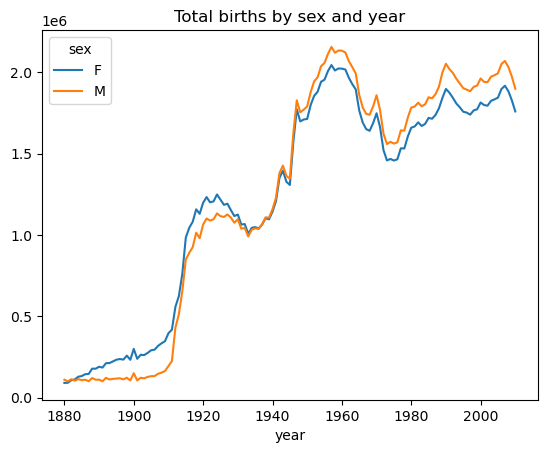

In [169]:
total_births.plot(title="Total births by sex and year")

In [173]:
def add_prop(group):
    group["prop"]=group["births"]/group["births"].sum()
    return group
names=names.groupby(["year","sex"],group_keys=False).apply(add_prop)

C:\Users\sansp\AppData\Local\Temp\ipykernel_18700\46757724.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  names=names.groupby(["year","sex"],group_keys=False).apply(add_prop)


In [174]:
names

,name,sex,births,year,prop
0,Mary,F,7065,1880,0.077643
1,Anna,F,2604,1880,0.028618
2,Emma,F,2003,1880,0.022013
3,Elizabeth,F,1939,1880,0.021309
4,Minnie,F,1746,1880,0.019188
...,...,...,...,...,...
1690779,Zymaire,M,5,2010,0.000003
1690780,Zyonne,M,5,2010,0.000003
1690781,Zyquarius,M,5,2010,0.000003
1690782,Zyran,M,5,2010,0.000003


In [175]:
names.groupby(["year","sex"])["prop"].sum()

year  sex
1880  F      1.0
      M      1.0
1881  F      1.0
      M      1.0
1882  F      1.0
            ... 
2008  M      1.0
2009  F      1.0
      M      1.0
2010  F      1.0
      M      1.0
Name: prop, Length: 262, dtype: float64

In [176]:
def get_top1000(group):
    return group.sort_values("births",ascending=False)[:1000]

In [177]:
grouped=names.groupby(["year","sex"])

In [178]:
top1000=grouped.apply(get_top1000)

C:\Users\sansp\AppData\Local\Temp\ipykernel_18700\3248747458.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top1000=grouped.apply(get_top1000)


In [179]:
top1000.head()

name sex  births  year      prop
year sex                                         
1880 F   0       Mary   F    7065  1880  0.077643
         1       Anna   F    2604  1880  0.028618
         2       Emma   F    2003  1880  0.022013
         3  Elizabeth   F    1939  1880  0.021309
         4     Minnie   F    1746  1880  0.019188

In [180]:
top1000=top1000.reset_index(drop=True)

In [181]:
top1000.head()

,name,sex,births,year,prop
0,Mary,F,7065,1880,0.077643
1,Anna,F,2604,1880,0.028618
2,Emma,F,2003,1880,0.022013
3,Elizabeth,F,1939,1880,0.021309
4,Minnie,F,1746,1880,0.019188


In [182]:
boys=top1000[top1000["sex"]=="M"]

In [183]:
girls=top1000[top1000["sex"]=="F"]

In [184]:
total_births=top1000.pivot_table("births",index="year",columns="name",aggfunc="sum")

In [185]:
total_births.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131 entries, 1880 to 2010
Columns: 6849 entries, Aaden to Zuri
dtypes: float64(6849)
memory usage: 6.8 MB


In [187]:
subset=total_births[["John","Harry","Mary","Marilyn"]]

array([<Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>, <Axes: xlabel='year'>], dtype=object)

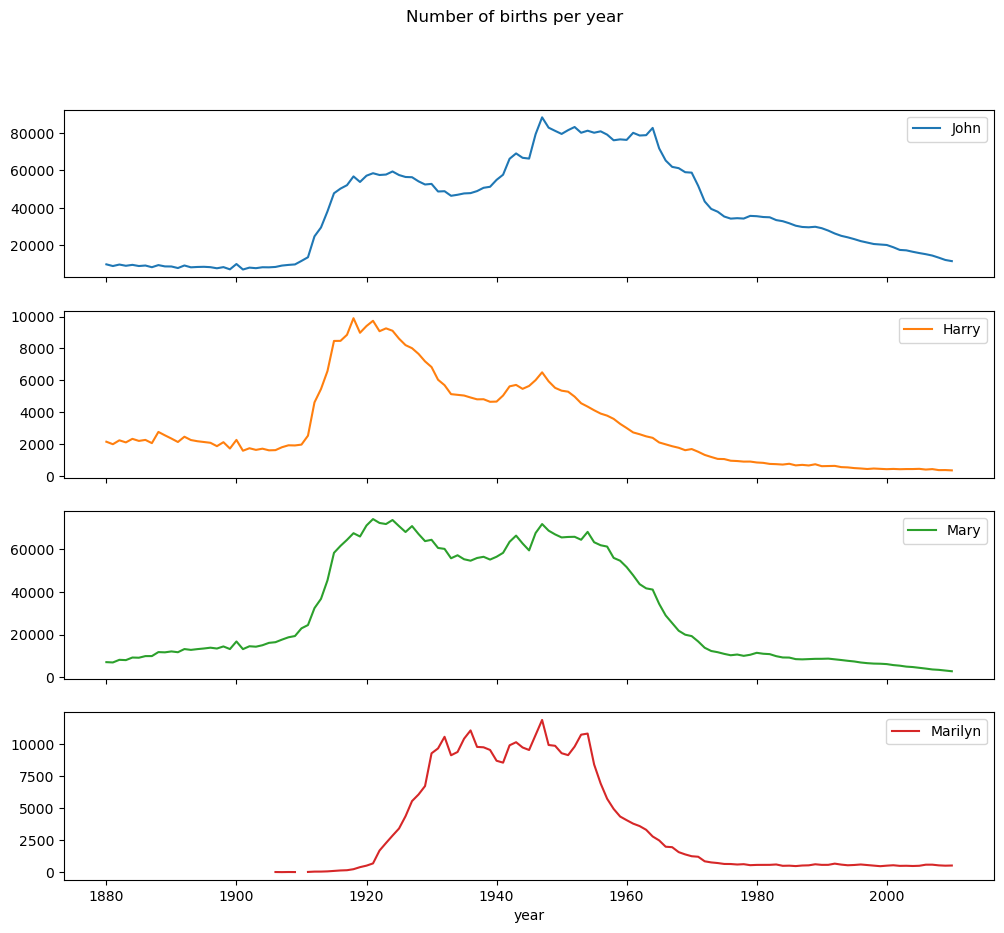

In [188]:
subset.plot(subplots=True,figsize=(12,10),title="Number of births per year")

In [189]:
table=top1000.pivot_table("prop",index="year",columns="sex",aggfunc="sum")

<Axes: title={'center': 'Sum of table1000.prop by year and sex'}, xlabel='year'>

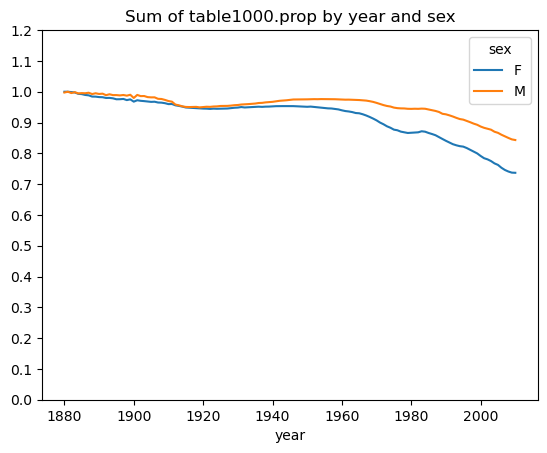

In [190]:
table.plot(title="Sum of table1000.prop by year and sex",
          yticks=np.linspace(0,1.2,13))

In [191]:
df=boys[boys["year"]==2010]

In [192]:
df

,name,sex,births,year,prop
260877,Jacob,M,21875,2010,0.011523
260878,Ethan,M,17866,2010,0.009411
260879,Michael,M,17133,2010,0.009025
260880,Jayden,M,17030,2010,0.008971
260881,William,M,16870,2010,0.008887
...,...,...,...,...,...
261872,Jaydan,M,194,2010,0.000102
261873,Camilo,M,194,2010,0.000102
261874,Bailey,M,194,2010,0.000102
261875,Destin,M,194,2010,0.000102


In [193]:
prop_cumsum=df["prop"].sort_values(ascending=False).cumsum()

In [194]:
prop_cumsum[:10]

260877    0.011523
260878    0.020934
260879    0.029959
260880    0.038930
260881    0.047817
260882    0.056579
260883    0.065155
260884    0.073414
260885    0.081528
260886    0.089621
Name: prop, dtype: float64

In [195]:
prop_cumsum.searchsorted(0.5)

np.int64(116)

In [196]:
df=boys[boys.year==1900]

In [197]:
int1900=df.sort_values("prop",ascending=False).prop.cumsum()

In [201]:
int1900.searchsorted(0.5)+1

np.int64(25)

In [202]:
def get_quantile_count(group,q=0.5):
    group=group.sort_values("prop",ascending=False)
    return group.prop.cumsum().searchsorted(q)+1

In [204]:
diversity=top1000.groupby(["year","sex"]).apply(get_quantile_count,include_groups=False)

In [205]:
diversity=diversity.unstack()

In [206]:
diversity.head()

sex,F,M
year,,
1880,38,14
1881,38,14
1882,38,15
1883,39,15
1884,39,16


<Axes: title={'center': 'Number of popular names in top 50%'}, xlabel='year'>

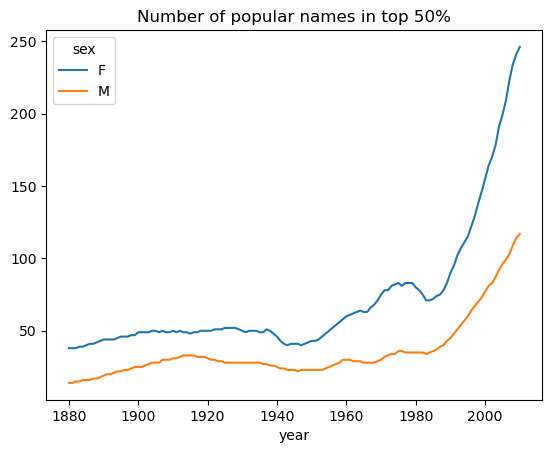

In [207]:
diversity.plot(title="Number of popular names in top 50%")

In [208]:
def get_last_letter(x):
    return x[-1]
last_letters=names["name"].map(get_last_letter)
last_letters.name="last_letter"
table=names.pivot_table("births",index=last_letters,
                       columns=["sex","year"],aggfunc="sum")

In [210]:
subtable=table.reindex(columns=[1910,1960,2010],level="year")

In [211]:
subtable.head()

sex                 F                            M                    
year             1910      1960      2010     1910      1960      2010
last_letter                                                           
a            108376.0  691247.0  670605.0    977.0    5204.0   28438.0
b                 NaN     694.0     450.0    411.0    3912.0   38859.0
c                 5.0      49.0     946.0    482.0   15476.0   23125.0
d              6750.0    3729.0    2607.0  22111.0  262112.0   44398.0
e            133569.0  435013.0  313833.0  28655.0  178823.0  129012.0

In [212]:
subtable.sum()

sex  year
F    1910     396416.0
     1960    2022062.0
     2010    1759010.0
M    1910     194198.0
     1960    2132588.0
     2010    1898382.0
dtype: float64

In [213]:
letter_prop=subtable/subtable.sum()

In [214]:
letter_prop

sex                 F                             M                    
year             1910      1960      2010      1910      1960      2010
last_letter                                                            
a            0.273390  0.341853  0.381240  0.005031  0.002440  0.014980
b                 NaN  0.000343  0.000256  0.002116  0.001834  0.020470
c            0.000013  0.000024  0.000538  0.002482  0.007257  0.012181
d            0.017028  0.001844  0.001482  0.113858  0.122908  0.023387
e            0.336941  0.215133  0.178415  0.147556  0.083853  0.067959
...               ...       ...       ...       ...       ...       ...
v                 NaN  0.000060  0.000117  0.000113  0.000037  0.001434
w            0.000020  0.000031  0.001182  0.006329  0.007711  0.016148
x            0.000015  0.000037  0.000727  0.003965  0.001851  0.008614
y            0.110972  0.152569  0.116828  0.077349  0.160987  0.058168
z            0.002439  0.000659  0.000704  0.000170  0.000184  0.001831

[26 rows x 6 columns]

In [215]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'Female'}, xlabel='last_letter'>

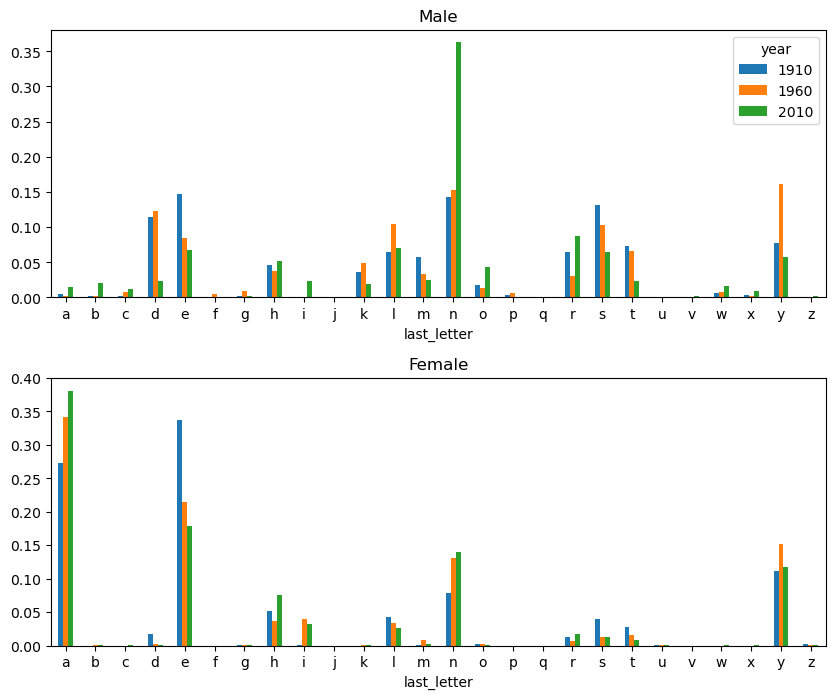

In [221]:
fig,axes=plt.subplots(2,1,figsize=(10,8))
plt.subplots_adjust(hspace=0.3)
letter_prop["M"].plot(kind="bar",rot=0,ax=axes[0],title="Male")
letter_prop["F"].plot(kind="bar",rot=0,ax=axes[1],title="Female",legend=False)

In [222]:
letter_prop=table/table.sum()

In [223]:
dny_ts=letter_prop.loc[["d","n","y"],"M"].T

In [224]:
dny_ts.head()

last_letter,d,n,y
year,,,
1880,0.083055,0.153213,0.075760
1881,0.083247,0.153214,0.077451
1882,0.085340,0.149560,0.077537
1883,0.084066,0.151646,0.079144
1884,0.086120,0.149915,0.080405


<Axes: xlabel='year'>

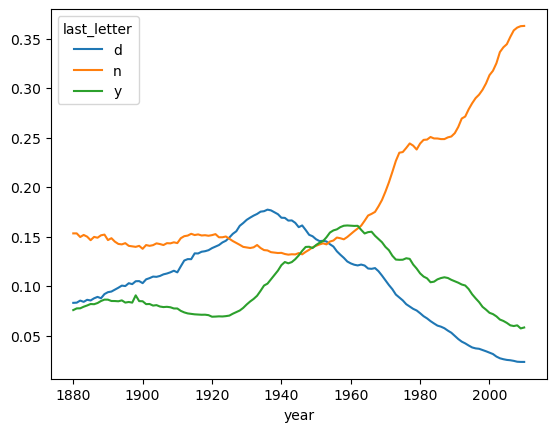

In [225]:
dny_ts.plot()

In [226]:
all_names=pd.Series(top1000["name"].unique())

In [229]:
lesley_like=all_names[all_names.str.contains("Lesl")]

In [230]:
lesley_like

645     Leslie
2325    Lesley
4241    Leslee
4706     Lesli
6082     Lesly
dtype: object

In [233]:
filtered=top1000[top1000["name"].isin(lesley_like)]

In [234]:
filtered.groupby("name")["births"].sum()

name
Leslee       916
Lesley     35010
Lesli        929
Leslie    370429
Lesly      10067
Name: births, dtype: int64

In [235]:
table=filtered.pivot_table("births",index="year",columns="sex",aggfunc="sum")

In [236]:
table=table.div(table.sum(axis="columns"),axis="index")

In [237]:
table.tail()

sex,F,M
year,,
2006,1.0,NaN
2007,1.0,NaN
2008,1.0,NaN
2009,1.0,NaN
2010,1.0,NaN


<Axes: xlabel='year'>

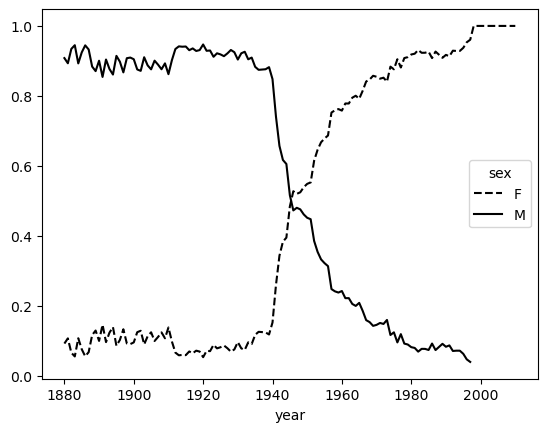

In [238]:
table.plot(style={"M":"k-","F":"k--"})

In [239]:
import json

In [241]:
db=json.load(open("database.json"))

In [242]:
len(db)

6636

In [243]:
db[0].keys()

dict_keys(['id', 'description', 'tags', 'manufacturer', 'group', 'portions', 'nutrients'])

In [244]:
db[0]["nutrients"][0]

{'value': 25.18,
 'units': 'g',
 'description': 'Protein',
 'group': 'Composition'}

In [245]:
nutrients=pd.DataFrame(db[0]["nutrients"])

In [247]:
nutrients.head(7)

,value,units,description,group
0,25.18,g,Protein,Composition
1,29.20,g,Total lipid (fat),Composition
2,3.06,g,"Carbohydrate, by difference",Composition
3,3.28,g,Ash,Other
4,376.00,kcal,Energy,Energy
5,39.28,g,Water,Composition
6,1573.00,kJ,Energy,Energy


In [248]:
info_keys=["description","group","id","manufacturer"]

In [249]:
info=pd.DataFrame(db,columns=info_keys)

In [250]:
info.head()

,description,group,id,manufacturer
0,"Cheese, caraway",Dairy and Egg Products,1008,
1,"Cheese, cheddar",Dairy and Egg Products,1009,
2,"Cheese, edam",Dairy and Egg Products,1018,
3,"Cheese, feta",Dairy and Egg Products,1019,
4,"Cheese, mozzarella, part skim milk",Dairy and Egg Products,1028,


In [251]:
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6636 entries, 0 to 6635
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   description   6636 non-null   object
 1   group         6636 non-null   object
 2   id            6636 non-null   int64 
 3   manufacturer  5195 non-null   object
dtypes: int64(1), object(3)
memory usage: 207.5+ KB


In [252]:
pd.value_counts(info["group"])[:10]

C:\Users\sansp\AppData\Local\Temp\ipykernel_18700\3634668934.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(info["group"])[:10]


group
Vegetables and Vegetable Products    812
Beef Products                        618
Baked Products                       496
Breakfast Cereals                    403
Legumes and Legume Products          365
Fast Foods                           365
Lamb, Veal, and Game Products        345
Sweets                               341
Fruits and Fruit Juices              328
Pork Products                        328
Name: count, dtype: int64

In [254]:
nutrients=[]
for rec in db:
    funts=pd.DataFrame(rec["nutrients"])
    funts["id"]=rec["id"]
    nutrients.append(funts)

nutrients=pd.concat(nutrients,ignore_index=True)

In [255]:
nutrients

,value,units,description,group,id
0,25.180,g,Protein,Composition,1008
1,29.200,g,Total lipid (fat),Composition,1008
2,3.060,g,"Carbohydrate, by difference",Composition,1008
3,3.280,g,Ash,Other,1008
4,376.000,kcal,Energy,Energy,1008
...,...,...,...,...,...
389350,0.000,mcg,"Vitamin B-12, added",Vitamins,43546
389351,0.000,mg,Cholesterol,Other,43546
389352,0.072,g,"Fatty acids, total saturated",Other,43546
389353,0.028,g,"Fatty acids, total monounsaturated",Other,43546


In [256]:
nutrients.duplicated().sum()

np.int64(14179)

In [257]:
nutrients=nutrients.drop_duplicates()

In [259]:
col_mapping={"description":"food","group":"fgroup"}

In [260]:
info=info.rename(columns=col_mapping,copy=False)

In [261]:
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6636 entries, 0 to 6635
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   food          6636 non-null   object
 1   fgroup        6636 non-null   object
 2   id            6636 non-null   int64 
 3   manufacturer  5195 non-null   object
dtypes: int64(1), object(3)
memory usage: 207.5+ KB


In [262]:
col_mapping={"description":"nutrient","group":"nutgroup"}

In [263]:
nutrients=nutrients.rename(columns=col_mapping,copy=False)

In [264]:
nutrients

,value,units,nutrient,nutgroup,id
0,25.180,g,Protein,Composition,1008
1,29.200,g,Total lipid (fat),Composition,1008
2,3.060,g,"Carbohydrate, by difference",Composition,1008
3,3.280,g,Ash,Other,1008
4,376.000,kcal,Energy,Energy,1008
...,...,...,...,...,...
389350,0.000,mcg,"Vitamin B-12, added",Vitamins,43546
389351,0.000,mg,Cholesterol,Other,43546
389352,0.072,g,"Fatty acids, total saturated",Other,43546
389353,0.028,g,"Fatty acids, total monounsaturated",Other,43546


In [265]:
ndata=pd.merge(nutrients,info,on="id")

In [266]:
ndata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375176 entries, 0 to 375175
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   value         375176 non-null  float64
 1   units         375176 non-null  object 
 2   nutrient      375176 non-null  object 
 3   nutgroup      375176 non-null  object 
 4   id            375176 non-null  int64  
 5   food          375176 non-null  object 
 6   fgroup        375176 non-null  object 
 7   manufacturer  293054 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 22.9+ MB


In [267]:
ndata.iloc[30000]

value                                             0.04
units                                                g
nutrient                                       Glycine
nutgroup                                   Amino Acids
id                                                6158
food            Soup, tomato bisque, canned, condensed
fgroup                      Soups, Sauces, and Gravies
manufacturer                                          
Name: 30000, dtype: object

In [268]:
result=ndata.groupby(["nutrient","fgroup"])["value"].quantile(0.5)

<Axes: ylabel='fgroup'>

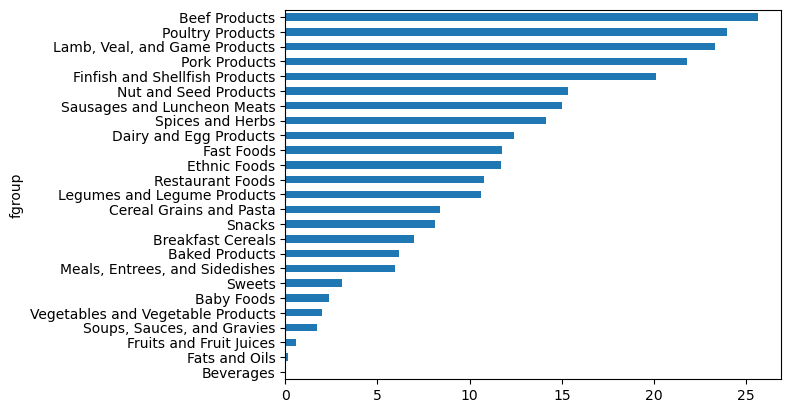

In [271]:
result["Protein"].sort_values().plot(kind="barh")

In [272]:
by_nutrient=ndata.groupby(["nutgroup","nutrient"])

In [274]:
def get_maximum(x):
    return x.loc[x.value.idxmax()]

max_foods=by_nutrient.apply(get_maximum)[["value","food"]]

C:\Users\sansp\AppData\Local\Temp\ipykernel_18700\648695173.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  max_foods=by_nutrient.apply(get_maximum)[["value","food"]]


In [275]:
max_foods["food"]=max_foods["food"].str[:50]

In [276]:
max_foods.loc["Amino Acids"]["food"]

nutrient
Alanine                            Gelatins, dry powder, unsweetened
Arginine                                Seeds, sesame flour, low-fat
Aspartic acid                                    Soy protein isolate
Cystine                 Seeds, cottonseed flour, low fat (glandless)
Glutamic acid                                    Soy protein isolate
Glycine                            Gelatins, dry powder, unsweetened
Histidine                 Whale, beluga, meat, dried (Alaska Native)
Hydroxyproline    KENTUCKY FRIED CHICKEN, Fried Chicken, ORIGINAL RE
Isoleucine        Soy protein isolate, PROTEIN TECHNOLOGIES INTERNAT
Leucine           Soy protein isolate, PROTEIN TECHNOLOGIES INTERNAT
Lysine            Seal, bearded (Oogruk), meat, dried (Alaska Native
Methionine                     Fish, cod, Atlantic, dried and salted
Phenylalanine     Soy protein isolate, PROTEIN TECHNOLOGIES INTERNAT
Proline                            Gelatins, dry powder, unsweetened
Serine            Soy pro

In [278]:
fec=pd.read_csv("P00000001-ALL.csv",low_memory=False)
#low_memoryを切ることでメモリ節約より正確さを優先する

In [279]:
fec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001731 entries, 0 to 1001730
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   cmte_id            1001731 non-null  object 
 1   cand_id            1001731 non-null  object 
 2   cand_nm            1001731 non-null  object 
 3   contbr_nm          1001731 non-null  object 
 4   contbr_city        1001712 non-null  object 
 5   contbr_st          1001727 non-null  object 
 6   contbr_zip         1001620 non-null  object 
 7   contbr_employer    988002 non-null   object 
 8   contbr_occupation  993301 non-null   object 
 9   contb_receipt_amt  1001731 non-null  float64
 10  contb_receipt_dt   1001731 non-null  object 
 11  receipt_desc       14166 non-null    object 
 12  memo_cd            92482 non-null    object 
 13  memo_text          97770 non-null    object 
 14  form_tp            1001731 non-null  object 
 15  file_num           1001731 non-n

In [280]:
fec.iloc[123456]

cmte_id                             C00431445
cand_id                             P80003338
cand_nm                         Obama, Barack
contbr_nm                         ELLMAN, IRA
contbr_city                             TEMPE
contbr_st                                  AZ
contbr_zip                          852816719
contbr_employer      ARIZONA STATE UNIVERSITY
contbr_occupation                   PROFESSOR
contb_receipt_amt                        50.0
contb_receipt_dt                    01-DEC-11
receipt_desc                              NaN
memo_cd                                   NaN
memo_text                                 NaN
form_tp                                 SA17A
file_num                               772372
Name: 123456, dtype: object

In [283]:
unique_cands=fec["cand_nm"].unique()

In [284]:
unique_cands

array(['Bachmann, Michelle', 'Romney, Mitt', 'Obama, Barack',
       "Roemer, Charles E. 'Buddy' III", 'Pawlenty, Timothy',
       'Johnson, Gary Earl', 'Paul, Ron', 'Santorum, Rick',
       'Cain, Herman', 'Gingrich, Newt', 'McCotter, Thaddeus G',
       'Huntsman, Jon', 'Perry, Rick'], dtype=object)

In [285]:
unique_cands[2]

'Obama, Barack'

In [287]:
patries={"Bachmann, Michelle":"Republican",
        "Cain, Herman":"Republican",
        "Gingrich, Newt":"Republican",
        "Huntsman, Jon":"Republican",
        "Johnson, Gary Earl":"Republican",
        "McCotter,Thaddeus G":"Republican",
        "Obama, Barack":"Democrat",
        "Paul, Ron":"Republican",
        "Pawlenty, Timothy":"Republican",
        "Perry, Rick":"Republican",
        "Roemer, Charles E. 'Buddy' III":"Republican",
        "Romney, Mitt":"Republican",
        "Santorum, Rick":"Republican"}

In [288]:
fec["cand_nm"][123456:123461]

123456    Obama, Barack
123457    Obama, Barack
123458    Obama, Barack
123459    Obama, Barack
123460    Obama, Barack
Name: cand_nm, dtype: object

In [289]:
fec["cand_nm"][123456:123461].map(patries)

123456    Democrat
123457    Democrat
123458    Democrat
123459    Democrat
123460    Democrat
Name: cand_nm, dtype: object

In [290]:
fec["party"]=fec["cand_nm"].map(patries)

In [291]:
fec["party"].value_counts()

party
Democrat      593746
Republican    407911
Name: count, dtype: int64

In [292]:
(fec["contb_receipt_amt"]>0).value_counts()

contb_receipt_amt
True     991475
False     10256
Name: count, dtype: int64

In [293]:
fec=fec[fec["contb_receipt_amt"]>0]

In [294]:
fec_mrbo=fec[fec["cand_nm"].isin(["Obama, Barack","Romney, Mitt"])]

In [295]:
fec["contbr_occupation"].value_counts()[:10]

contbr_occupation
RETIRED                                   233990
INFORMATION REQUESTED                      35107
ATTORNEY                                   34286
HOMEMAKER                                  29931
PHYSICIAN                                  23432
INFORMATION REQUESTED PER BEST EFFORTS     21138
ENGINEER                                   14334
TEACHER                                    13990
CONSULTANT                                 13273
PROFESSOR                                  12555
Name: count, dtype: int64

In [309]:
occ_mapping={
    "INFORMATION REQUESTED PER BEST EFFORT":"NOT PROVIDED",
    "INFORMATION REQUESTED":"NOT PROVIDED",
    "INFORMATION REQUESTED (BEST EFFORT)":"NOT PROVIDED",
    "C.E.O.":"CEO"
}

In [310]:
def get_occ(x):
    return occ_mapping.get(x,x)

fec["contbr_occupation"]=fec["contbr_occupation"].map(get_occ)

In [311]:
emp_mapping={
    "INFORMATION REQUESTED PER BEST EFFORTS":"NOT PROVIDED",
    "INFORMATION REQUESTED":"NOT PROVIDED",
    "SELF":"SELF-EMPLOYED",
    "SELF EMPLOYED":"SELF-EMPLOYED",
}

In [312]:
def get_emp(x):
    return emp_mapping.get(x,x)

In [313]:
fec["contbr_employer"]=fec["contbr_employer"].map(get_emp)

In [314]:
by_occupation=fec.pivot_table("contb_receipt_amt",index="contbr_occupation",
                             columns="party",aggfunc="sum")

In [315]:
over_2mm=by_occupation[by_occupation.sum(axis="columns")>2000000]

In [316]:
over_2mm

party,Democrat,Republican
contbr_occupation,,
ATTORNEY,11141982.97,7476694.43
CEO,2075974.79,4233491.52
CONSULTANT,2459912.71,2544725.45
ENGINEER,951525.55,1816973.70
EXECUTIVE,1355161.05,4135100.09
HOMEMAKER,4248875.80,13629875.78
INFORMATION REQUESTED PER BEST EFFORTS,NaN,16340533.64
INVESTOR,884133.00,2431768.92
LAWYER,3160478.87,390724.32


<Axes: ylabel='contbr_occupation'>

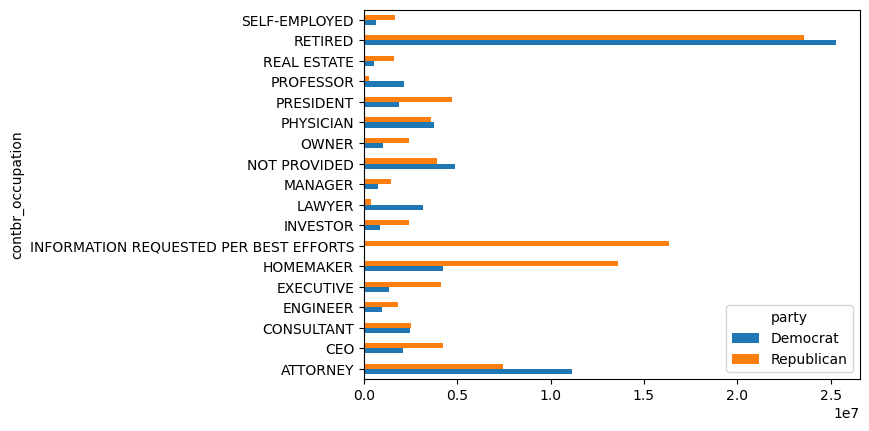

In [317]:
over_2mm.plot(kind="barh")

In [318]:
def get_top_amounts(group,key,n=5):
    totals=group.groupby(key)["contb_receipt_amt"].sum()
    return totals.nlargest(n)

In [319]:
grouped=fec_mrbo.groupby("cand_nm")
grouped.apply(get_top_amounts,"contbr_occupation",n=7)

C:\Users\sansp\AppData\Local\Temp\ipykernel_18700\978162504.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped.apply(get_top_amounts,"contbr_occupation",n=7)


cand_nm        contbr_occupation                     
Obama, Barack  RETIRED                                   25305116.38
               ATTORNEY                                  11141982.97
               INFORMATION REQUESTED                      4866973.96
               HOMEMAKER                                  4248875.80
               PHYSICIAN                                  3735124.94
               LAWYER                                     3160478.87
               CONSULTANT                                 2459912.71
Romney, Mitt   RETIRED                                   11508473.59
               INFORMATION REQUESTED PER BEST EFFORTS    11396894.84
               HOMEMAKER                                  8147446.22
               ATTORNEY                                   5364718.82
               PRESIDENT                                  2491244.89
               EXECUTIVE                                  2300947.03
               C.E.O.                            

In [320]:
grouped.apply(get_top_amounts,"contbr_employer",n=10)

C:\Users\sansp\AppData\Local\Temp\ipykernel_18700\512717516.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped.apply(get_top_amounts,"contbr_employer",n=10)


cand_nm        contbr_employer                       
Obama, Barack  RETIRED                                   22694358.85
               SELF-EMPLOYED                             17080985.96
               NOT EMPLOYED                               8586308.70
               INFORMATION REQUESTED                      5053480.37
               HOMEMAKER                                  2605408.54
               SELF                                       1076531.20
               SELF EMPLOYED                               469290.00
               STUDENT                                     318831.45
               VOLUNTEER                                   257104.00
               MICROSOFT                                   215585.36
Romney, Mitt   INFORMATION REQUESTED PER BEST EFFORTS    12059527.24
               RETIRED                                   11506225.71
               HOMEMAKER                                  8147196.22
               SELF-EMPLOYED                     

In [321]:
bins=np.array([0,1,10,100,1000,10000,100_000,1_000_000,10_000_000])

In [322]:
labels=pd.cut(fec_mrbo["contb_receipt_amt"],bins)

In [323]:
labels

411         (10, 100]
412       (100, 1000]
413       (100, 1000]
414         (10, 100]
415         (10, 100]
             ...     
701381      (10, 100]
701382    (100, 1000]
701383        (1, 10]
701384      (10, 100]
701385    (100, 1000]
Name: contb_receipt_amt, Length: 694282, dtype: category
Categories (8, interval[int64, right]): [(0, 1] < (1, 10] < (10, 100] < (100, 1000] < (1000, 10000] < (10000, 100000] < (100000, 1000000] < (1000000, 10000000]]

In [324]:
grouped=fec_mrbo.groupby(["cand_nm",labels])

C:\Users\sansp\AppData\Local\Temp\ipykernel_18700\3103596316.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped=fec_mrbo.groupby(["cand_nm",labels])


In [325]:
grouped.size().unstack(level=0)

cand_nm,"Obama, Barack","Romney, Mitt"
contb_receipt_amt,,
"(0, 1]",493,77
"(1, 10]",40070,3681
"(10, 100]",372280,31853
"(100, 1000]",153991,43357
"(1000, 10000]",22284,26186
"(10000, 100000]",2,1
"(100000, 1000000]",3,0
"(1000000, 10000000]",4,0


In [326]:
bucket_sums=grouped["contb_receipt_amt"].sum().unstack(level=0)

In [327]:
normed_sums=bucket_sums.div(bucket_sums.sum(axis="columns"),axis="index")

In [328]:
normed_sums

cand_nm,"Obama, Barack","Romney, Mitt"
contb_receipt_amt,,
"(0, 1]",0.805182,0.194818
"(1, 10]",0.918767,0.081233
"(10, 100]",0.910769,0.089231
"(100, 1000]",0.710176,0.289824
"(1000, 10000]",0.447326,0.552674
"(10000, 100000]",0.823120,0.176880
"(100000, 1000000]",1.000000,0.000000
"(1000000, 10000000]",1.000000,0.000000


<Axes: ylabel='contb_receipt_amt'>

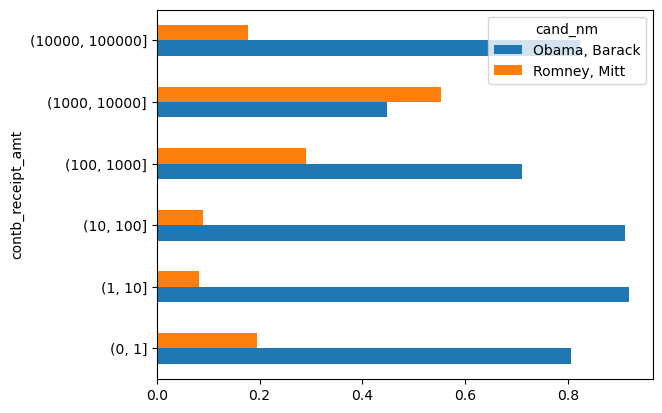

In [329]:
normed_sums[:-2].plot(kind="barh")

In [330]:
grouped=fec_mrbo.groupby(["cand_nm","contbr_st"])

In [333]:
totals=grouped["contb_receipt_amt"].sum().unstack(level=0).fillna(0)

In [334]:
totals=totals[totals.sum(axis="columns")>100000]

In [335]:
totals.head(10)

cand_nm,"Obama, Barack","Romney, Mitt"
contbr_st,,
AK,281840.15,86204.24
AL,543123.48,527303.51
AR,359247.28,105556.00
AZ,1506476.98,1888436.23
CA,23824984.24,11237636.60
CO,2132429.49,1506714.12
CT,2068291.26,3499475.45
DC,4373538.80,1025137.50
DE,336669.14,82712.00


In [336]:
percent=totals.div(totals.sum(axis="columns"),axis="index")

In [337]:
percent.head(10)

cand_nm,"Obama, Barack","Romney, Mitt"
contbr_st,,
AK,0.765778,0.234222
AL,0.507390,0.492610
AR,0.772902,0.227098
AZ,0.443745,0.556255
CA,0.679498,0.320502
CO,0.585970,0.414030
CT,0.371476,0.628524
DC,0.810113,0.189887
DE,0.802776,0.197224
